# Load Data

Dataset yang digunakan adalah "Diabetes Health Indicators Dataset" yang bersumber dari 
Kaggle (BRFSS 2015). Dataset ini berisi data survei kesehatan masyarakat Amerika Serikat 

In [24]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/alexteboul/diabetes-health-indicators-dataset/diabetes_binary_5050split_health_indicators_BRFSS2015.csv
/kaggle/input/datasets/alexteboul/diabetes-health-indicators-dataset/diabetes_binary_health_indicators_BRFSS2015.csv
/kaggle/input/datasets/alexteboul/diabetes-health-indicators-dataset/diabetes_012_health_indicators_BRFSS2015.csv


In [3]:
import pandas as pd

df = pd.read_csv(
    '/kaggle/input/datasets/alexteboul/diabetes-health-indicators-dataset/diabetes_binary_health_indicators_BRFSS2015.csv'
)

df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


# EDA

Pada tahap ini dilakukan eksplorasi awal untuk memahami struktur dan karakteristik dataset 
sebelum masuk ke proses pemodelan.

- `df.columns` → melihat nama-nama kolom yang tersedia dalam dataset
- `df.info()` → mengecek tipe data tiap kolom dan jumlah nilai non-null
- `df.isnull().sum()` → memastikan tidak ada missing value dalam dataset
- `df.duplicated().sum()` → mengecek apakah ada baris yang duplikat
- `df.describe()` → menampilkan statistik deskriptif seperti rata-rata, min, max, dan standar deviasi
- `value_counts()` → melihat distribusi kelas target (Diabetes vs Non-Diabetes), 
  baik dalam bentuk jumlah maupun persentase
- `df.corr()` → menghitung korelasi setiap fitur terhadap label Diabetes_binary 
  untuk mengetahui fitur mana yang paling berpengaruh

In [4]:
df.columns

Index(['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker',
       'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='object')

In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

In [29]:
df.describe()

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.139333,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,...,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,0.346294,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,...,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,1.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


Selain itu, dilakukan beberapa visualisasi:
- Bar chart distribusi kelas → untuk melihat ketimpangan jumlah antara kelas positif dan negatif
- Histogram fitur numerik → untuk melihat sebaran nilai pada fitur-fitur penting seperti BMI, Age, dll
- Heatmap korelasi → untuk melihat hubungan antar seluruh fitur secara sekaligus
- Boxplot → untuk mendeteksi outlier pada fitur BMI, MentHlth, dan PhysHlth

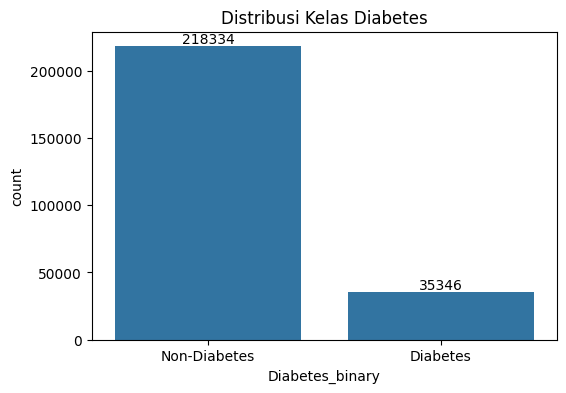

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribusi label
plt.figure(figsize=(6,4))
ax = sns.countplot(x='Diabetes_binary', data=df)
ax.bar_label(ax.containers[0])
plt.title('Distribusi Kelas Diabetes')
plt.xticks([0,1], ['Non-Diabetes', 'Diabetes'])
plt.show()

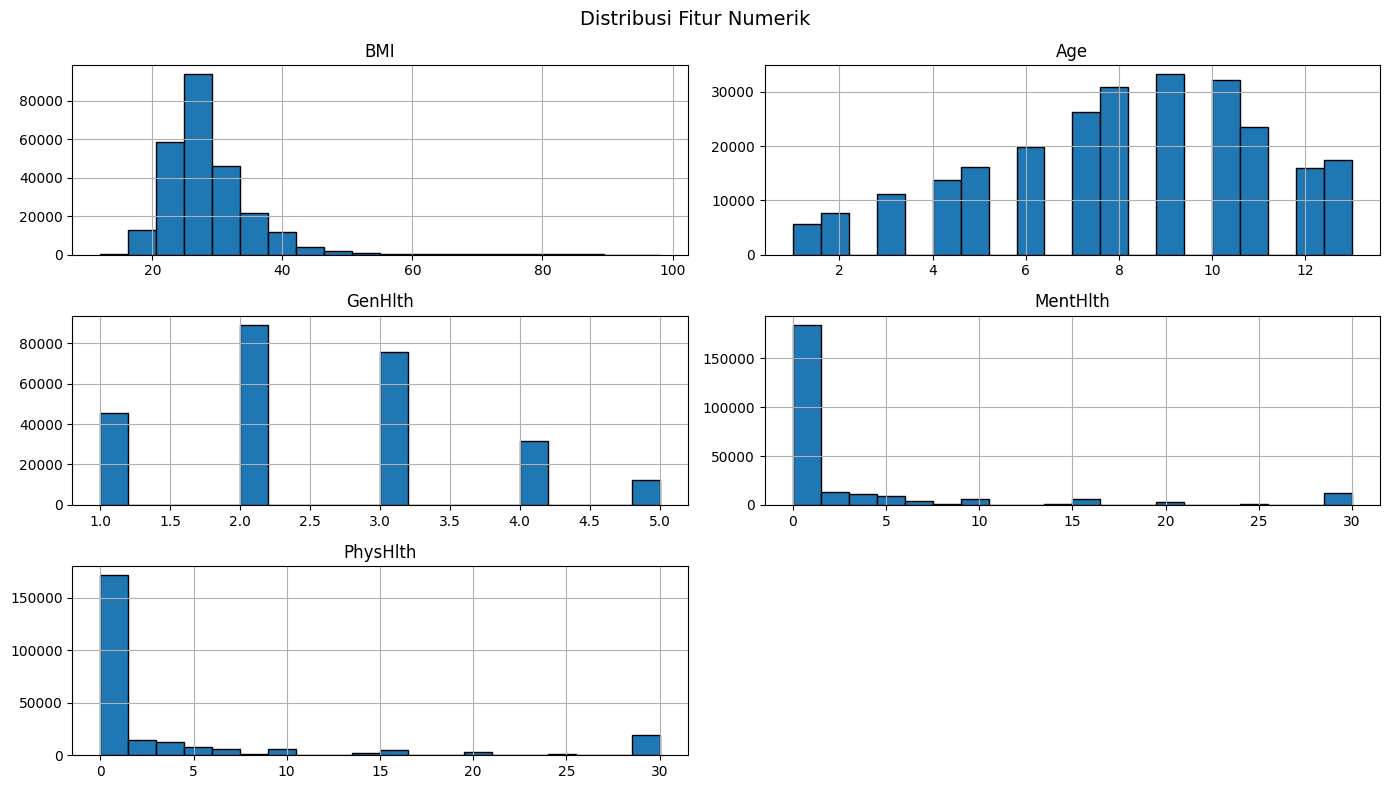

In [26]:
# Distribusi beberapa fitur penting
fitur_penting = ['BMI', 'Age', 'GenHlth', 'MentHlth', 'PhysHlth']

df[fitur_penting].hist(figsize=(14,8), bins=20, edgecolor='black')
plt.suptitle('Distribusi Fitur Numerik', fontsize=14)
plt.tight_layout()
plt.show()

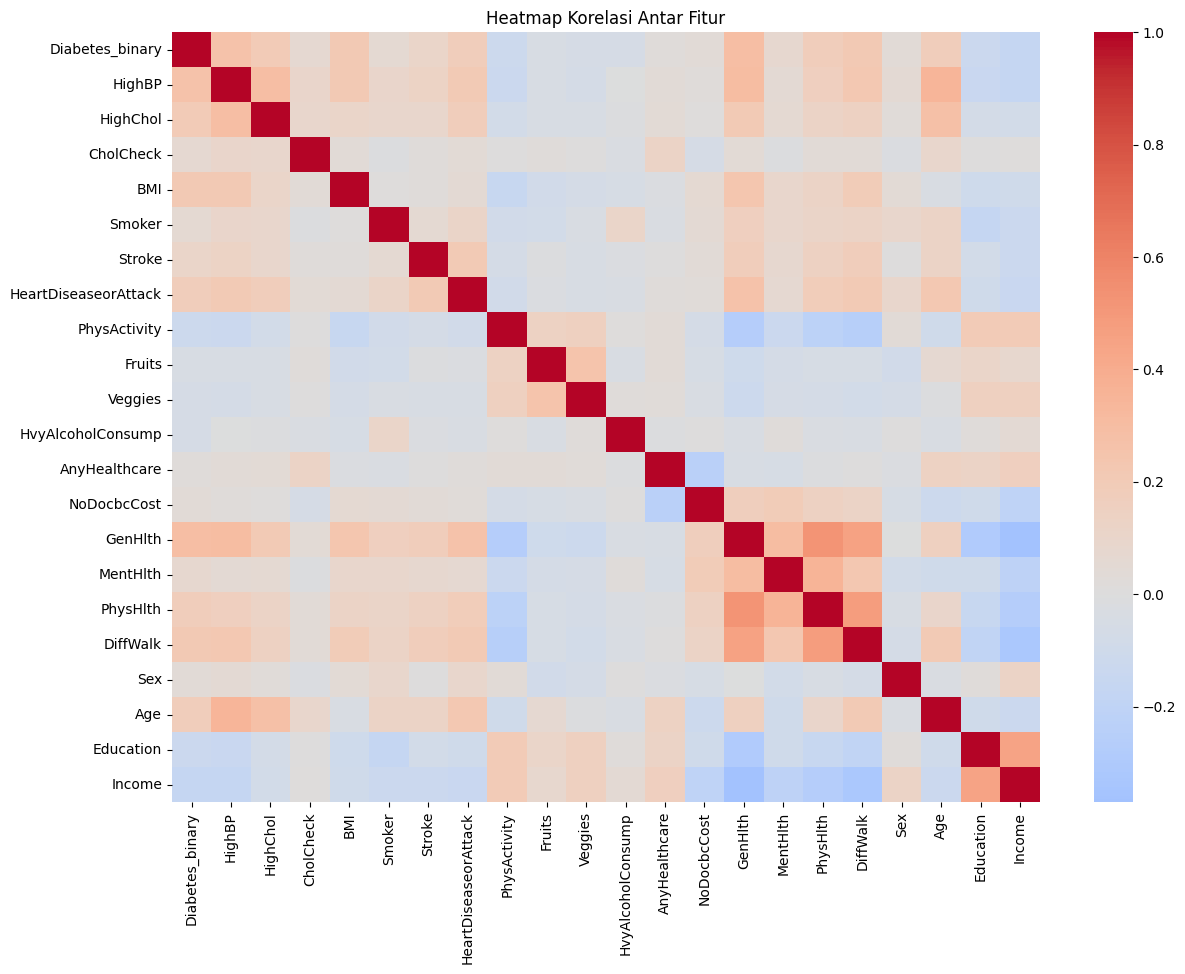

In [27]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm', center=0)
plt.title('Heatmap Korelasi Antar Fitur')
plt.show()

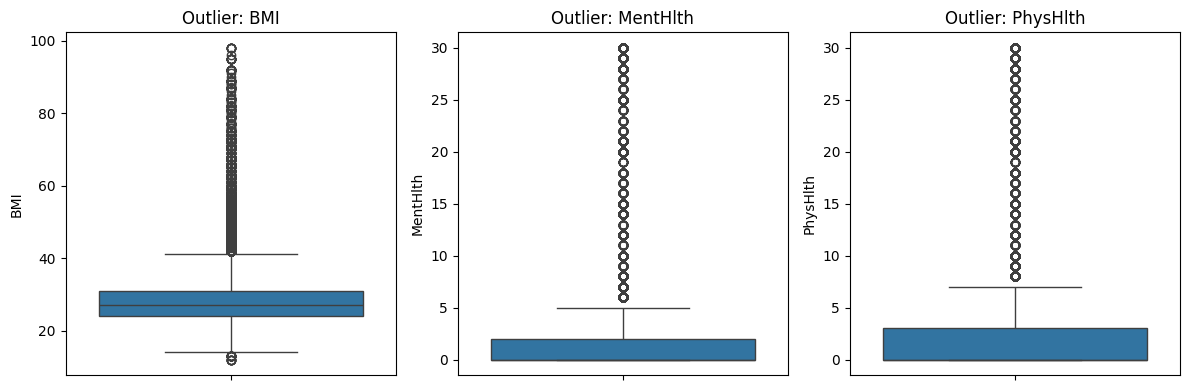

In [28]:
fitur_cek = ['BMI', 'MentHlth', 'PhysHlth']

plt.figure(figsize=(12,4))
for i, col in enumerate(fitur_cek, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df[col])
    plt.title(f'Outlier: {col}')
plt.tight_layout()
plt.show()

# Split Data
Sebelum melatih model, dilakukan pemisahan antara fitur (X) dan label target (y). 
Kolom `Diabetes_binary` dipisahkan sebagai variabel target, sementara kolom lainnya 
digunakan sebagai fitur input.

Data kemudian dibagi menjadi data latih (80%) dan data uji (20%) menggunakan 
`train_test_split`. Parameter `stratify=y` digunakan agar proporsi kelas positif 
dan negatif tetap seimbang di kedua subset, sehingga pembagian data tidak bias.

In [10]:
from sklearn.model_selection import train_test_split

X = df.drop('Diabetes_binary', axis=1)
y = df['Diabetes_binary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Training model

Pada tahap ini dilakukan pelatihan dua algoritma klasifikasi untuk kemudian dibandingkan 
kinerjanya, yaitu Random Forest dan XGBoost.

Kedua model dilatih menggunakan `RandomizedSearchCV` dengan 10 kombinasi hyperparameter 
yang dipilih secara acak dan divalidasi menggunakan 3-fold cross-validation. 
Metrik yang dioptimasi adalah ROC-AUC karena dataset mengalami ketidakseimbangan kelas.

Untuk menangani class imbalance:
- Random Forest menggunakan parameter `class_weight='balanced'`, sehingga model 
  memberi bobot lebih pada kelas minoritas (penderita diabetes)
- XGBoost menggunakan `scale_pos_weight`, yaitu rasio jumlah kelas negatif 
  dibanding positif, agar model tidak terlalu condong ke kelas mayoritas

Setelah proses tuning selesai, model terbaik dari masing-masing algoritma diambil 
menggunakan `.best_estimator_` untuk digunakan pada tahap evaluasi.

In [11]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

rf_params = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(
        class_weight='balanced',
        random_state=42
    ),
    param_distributions=rf_params,
    n_iter=10,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42
)

rf_search.fit(X_train, y_train)

print("Best RF:")
print(rf_search.best_params_)
print(rf_search.best_score_)

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best RF:
{'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 10}
0.8269957056547502


In [12]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print(scale_pos_weight)

6.176998974431517


In [13]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

xgb_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss',
        random_state=42
    ),
    param_distributions=xgb_params,
    n_iter=10,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42
)

xgb_search.fit(X_train, y_train)

print("Best XGB:")
print(xgb_search.best_params_)
print(xgb_search.best_score_)

Best XGB:
{'subsample': 1.0, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.9}
0.8303255056920196


In [14]:
best_rf = rf_search.best_estimator_
best_xgb = xgb_search.best_estimator_

# Evaluasi Model

Kedua model terbaik dievaluasi menggunakan data uji yang belum pernah dilihat model 
sebelumnya. Metrik yang digunakan meliputi:

- Accuracy → persentase prediksi yang benar secara keseluruhan
- Precision → dari yang diprediksi diabetes, berapa yang benar-benar diabetes
- Recall → dari yang benar-benar diabetes, berapa yang berhasil terdeteksi
- F1-Score → rata-rata harmonis antara precision dan recall
- ROC-AUC → kemampuan model membedakan kelas positif dan negatif


In [45]:
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score
)

def evaluate(model, X_test, y_test):
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:,1]
    return {
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1': f1_score(y_test, pred),
        'ROC_AUC': roc_auc_score(y_test, prob)
    }

rf_result = evaluate(best_rf, X_test, y_test)
xgb_result = evaluate(best_xgb, X_test, y_test)



In [41]:
from sklearn.metrics import classification_report

print("RF")
print(classification_report(y_test, best_rf.predict(X_test)))

print("XGB")
print(classification_report(y_test, best_xgb.predict(X_test)))

RF
              precision    recall  f1-score   support

         0.0       0.96      0.73      0.83     43667
         1.0       0.32      0.79      0.46      7069

    accuracy                           0.74     50736
   macro avg       0.64      0.76      0.64     50736
weighted avg       0.87      0.74      0.78     50736

XGB
              precision    recall  f1-score   support

         0.0       0.96      0.71      0.81     43667
         1.0       0.31      0.80      0.44      7069

    accuracy                           0.72     50736
   macro avg       0.63      0.75      0.63     50736
weighted avg       0.86      0.72      0.76     50736



Model Random Forest menghasilkan accuracy sebesar 74%, precision 32%, recall 79%, dan F1-score 46% pada kelas diabetes. Hasil ini menunjukkan bahwa model mampu mendeteksi sebagian besar kasus diabetes, meskipun masih menghasilkan cukup banyak prediksi positif yang tidak tepat.

Model XGBoost menghasilkan accuracy sebesar 72%, precision 31%, recall 80%, dan F1-score 44% pada kelas diabetes. Nilai recall yang lebih tinggi menunjukkan bahwa XGBoost lebih baik dalam mengidentifikasi penderita diabetes dibandingkan Random Forest.

# Visualisasi

Selain metrik numerik, dilakukan juga visualisasi:
- Classification report → ringkasan metrik per kelas
- Confusion matrix → melihat distribusi prediksi benar dan salah
- ROC Curve → membandingkan kurva performa kedua model secara visual
- Feature importance → menampilkan 10 fitur paling berpengaruh untuk masing-masing model



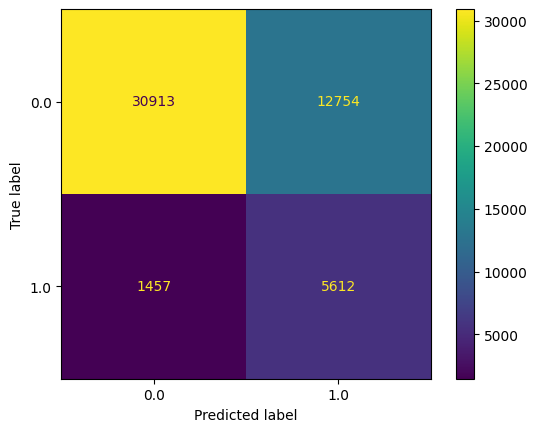

In [17]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(best_xgb, X_test, y_test)
plt.show()

Berdasarkan confusion matrix, model berhasil mengklasifikasikan 30.913 data non-diabetes dan 5.612 data diabetes dengan benar. Namun, masih terdapat 12.754 data non-diabetes yang diprediksi sebagai diabetes serta 1.457 data diabetes yang tidak berhasil terdeteksi. Hasil ini menunjukkan bahwa model memiliki kemampuan deteksi diabetes yang cukup baik dengan jumlah kesalahan prediksi negatif yang relatif rendah.

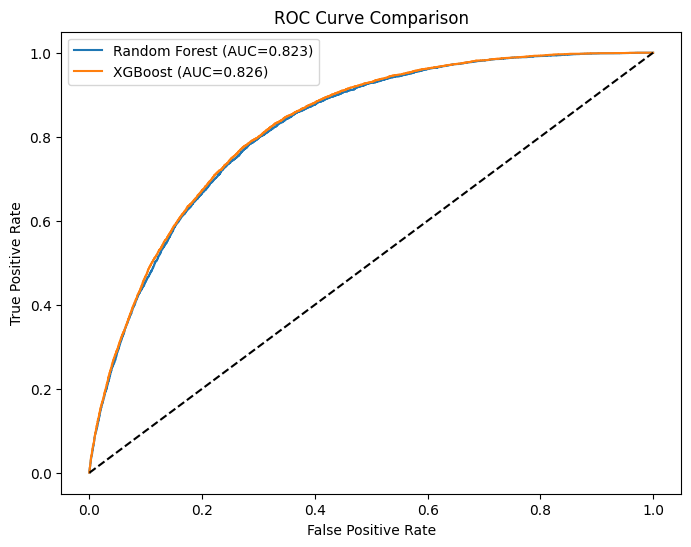

In [18]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

rf_prob = best_rf.predict_proba(X_test)[:,1]
xgb_prob = best_xgb.predict_proba(X_test)[:,1]

rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_prob)

plt.figure(figsize=(8,6))

plt.plot(rf_fpr, rf_tpr,
         label='Random Forest (AUC=0.823)')

plt.plot(xgb_fpr, xgb_tpr,
         label='XGBoost (AUC=0.826)')

plt.plot([0,1],[0,1],'k--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()

plt.show()

Kurva ROC menunjukkan bahwa kedua algoritma memiliki performa klasifikasi yang baik dengan nilai AUC di atas 0,82. XGBoost memperoleh nilai AUC sebesar 0,826, sedikit lebih tinggi dibandingkan Random Forest sebesar 0,823. Hal ini menunjukkan bahwa XGBoost memiliki kemampuan yang sedikit lebih baik dalam membedakan kelas diabetes dan non-diabetes.

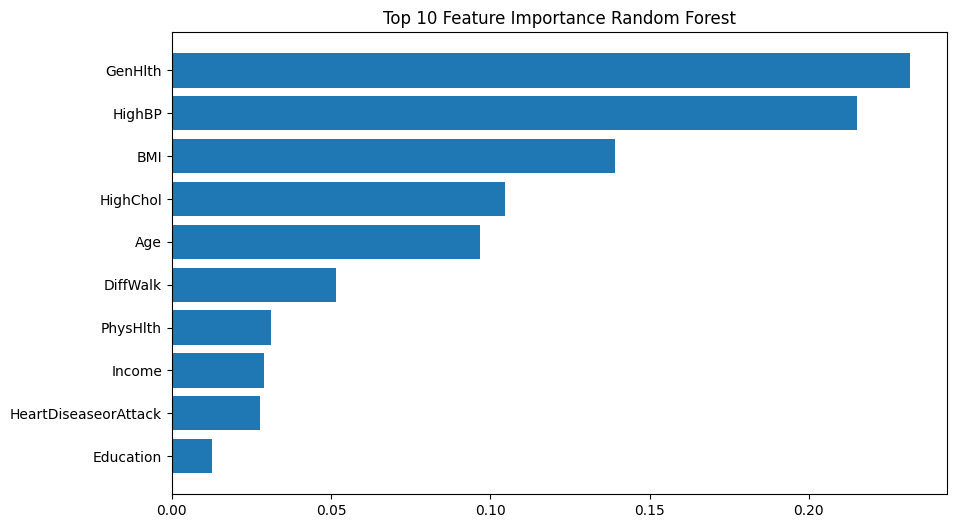

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

importance_rf = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
})

importance_rf = importance_rf.sort_values(
    'Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

plt.barh(
    importance_rf['Feature'][:10],
    importance_rf['Importance'][:10]
)

plt.title('Top 10 Feature Importance Random Forest')

plt.gca().invert_yaxis()

plt.show()

Berdasarkan hasil feature importance pada Random Forest, fitur yang paling berpengaruh terhadap prediksi diabetes adalah GenHlth, HighBP, BMI, HighChol, dan Age. Hasil ini menunjukkan bahwa kondisi kesehatan umum, tekanan darah tinggi, indeks massa tubuh, kolesterol tinggi, dan usia merupakan faktor utama yang memengaruhi risiko diabetes.

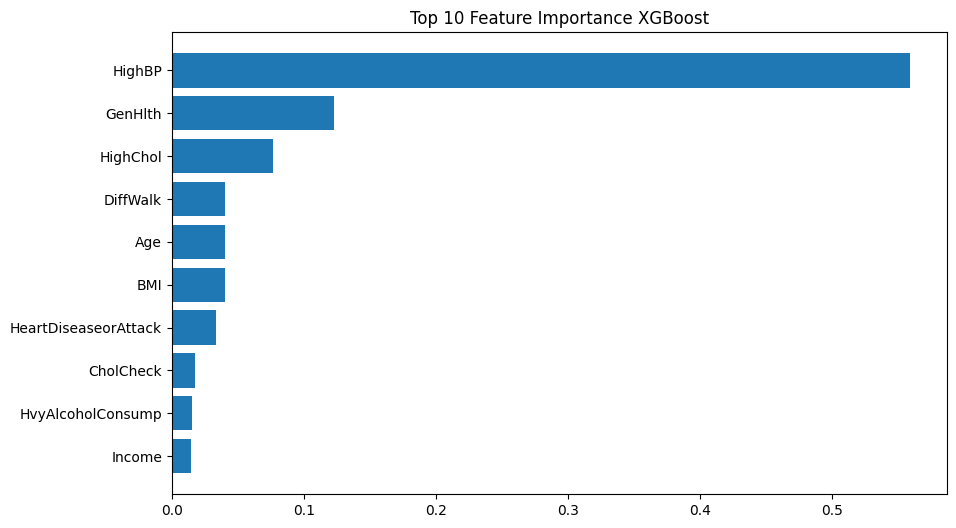

In [20]:
importance_xgb = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_xgb.feature_importances_
})

importance_xgb = importance_xgb.sort_values(
    'Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

plt.barh(
    importance_xgb['Feature'][:10],
    importance_xgb['Importance'][:10]
)

plt.title('Top 10 Feature Importance XGBoost')

plt.gca().invert_yaxis()

plt.show()

Pada model XGBoost, fitur HighBP menjadi faktor yang paling dominan, diikuti oleh GenHlth, HighChol, DiffWalk, Age, dan BMI. Hasil ini menunjukkan bahwa hipertensi memiliki kontribusi terbesar dalam proses klasifikasi risiko diabetes pada model XGBoost.

Terakhir, dilakukan uji statistik Wilcoxon Signed-Rank Test menggunakan 5-fold 
cross-validation untuk membuktikan apakah perbedaan kinerja antara kedua model 
signifikan secara statistik, bukan sekadar kebetulan dari satu kali percobaan.

In [34]:
from sklearn.model_selection import StratifiedKFold
from scipy.stats import wilcoxon
from sklearn.metrics import roc_auc_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rf_scores, xgb_scores = [], []

for train_idx, val_idx in skf.split(X, y):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    best_rf.fit(X_tr, y_tr)
    best_xgb.fit(X_tr, y_tr)

    rf_scores.append(roc_auc_score(y_val, best_rf.predict_proba(X_val)[:,1]))
    xgb_scores.append(roc_auc_score(y_val, best_xgb.predict_proba(X_val)[:,1]))

stat, p = wilcoxon(rf_scores, xgb_scores)
print(f"RF AUC per fold  : {[round(s,4) for s in rf_scores]}")
print(f"XGB AUC per fold : {[round(s,4) for s in xgb_scores]}")
print(f"\nWilcoxon p-value : {p:.4f}")
if p < 0.05:
    print("→ Perbedaan signifikan secara statistik (p < 0.05)")
else:
    print("→ Perbedaan TIDAK signifikan secara statistik (p ≥ 0.05)")

RF AUC per fold  : [np.float64(0.8305), np.float64(0.8264), np.float64(0.8269), np.float64(0.8264), np.float64(0.8221)]
XGB AUC per fold : [np.float64(0.8339), np.float64(0.829), np.float64(0.8299), np.float64(0.8301), np.float64(0.8253)]

Wilcoxon p-value : 0.0625
→ Perbedaan TIDAK signifikan secara statistik (p ≥ 0.05)


Hasil uji Wilcoxon menghasilkan nilai p-value sebesar 0,0625. Karena nilai p-value lebih besar dari 0,05, maka tidak terdapat perbedaan performa yang signifikan secara statistik antara algoritma Random Forest dan XGBoost. Meskipun XGBoost memperoleh nilai AUC yang sedikit lebih tinggi, keunggulan tersebut belum cukup untuk dinyatakan berbeda secara signifikan dari Random Forest.

Berdasarkan hasil evaluasi, Random Forest menghasilkan accuracy yang lebih tinggi, sedangkan XGBoost memperoleh recall dan nilai AUC yang sedikit lebih baik. Namun, hasil uji Wilcoxon menunjukkan bahwa perbedaan performa kedua algoritma tidak signifikan secara statistik. Oleh karena itu, kedua algoritma memiliki kinerja yang relatif setara dalam klasifikasi risiko diabetes pada dataset BRFSS 2015.